In [1]:
!pip install -q "gymnasium[mujoco]" mujoco torch numpy matplotlib
print("Done")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 14.3 MB/s eta 0:00:00
Done


In [2]:
import os, json, time, copy, math
from pathlib import Path
from collections import deque

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym
from gymnasium import Wrapper, ObservationWrapper
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ── Get Hopper-v5 dims ────────────────────────────────────────────────────────
_env = gym.make("Hopper-v5")
FULL_STATE_DIM = _env.observation_space.shape[0]   # 11
ACTION_DIM     = _env.action_space.shape[0]        # 3
MAX_ACTION     = float(_env.action_space.high[0])  # 1.0
_env.close()
print(f"Hopper-v5 full state dim : {FULL_STATE_DIM}")
print(f"Action dim               : {ACTION_DIM}")

# ── Hopper-v5 observation layout ──────────────────────────────────────────────
# Index  0      : z-position (height)
# Index  1      : angle (body pitch)
# Index  2- 4   : joint angles (3 joints)   ← POSITIONS
# Index  5      : x-velocity
# Index  6      : z-velocity
# Index  7      : pitch angular velocity
# Index  8-10   : joint angular velocities  ← VELOCITIES
VELOCITY_INDICES = [5, 6, 7, 8, 9, 10]   # 6 velocity dimensions
POSITION_INDICES = [0, 1, 2, 3, 4]        # 5 position/angle dimensions
HIDDEN_VEL_OBS_DIM = FULL_STATE_DIM - len(VELOCITY_INDICES)   # 5
print(f"\nVelocity indices (to hide): {VELOCITY_INDICES}")
print(f"Hidden-velocity obs dim   : {HIDDEN_VEL_OBS_DIM}")


Device: cuda
Hopper-v5 full state dim : 11
Action dim               : 3

Velocity indices (to hide): [5, 6, 7, 8, 9, 10]
Hidden-velocity obs dim   : 5


In [3]:
# ── TD3 hyperparameters (same for all conditions) ─────────────────────────────
TD3_CFG = {
    "env_name"      : "Hopper-v5",
    "seed"          : 42,
    "total_steps"   : 300_000,
    "warmup_steps"  : 25_000,
    "batch_size"    : 256,
    "discount"      : 0.99,
    "tau"           : 0.005,
    "policy_noise"  : 0.2,
    "noise_clip"    : 0.5,
    "policy_delay"  : 2,
    "expl_noise"    : 0.1,
    "buffer_size"   : 1_000_000,
    "eval_every"    : 10_000,
    "eval_episodes" : 10,
    "log_every"     : 2_000,
    "save_dir"      : "./checkpoints_rl_b3",
    "critic_hidden" : 256,
    "critic_lr"     : 3e-4,
    "actor_lr"      : 3e-4,   # MLP actor LR
    "tf_actor_lr"   : 1e-4,   # Transformer actor LR
}

# ── Transformer actor config (use best L from Phase B2) ──────────────────────
# Change BEST_L to whichever context length performed best in Phase B2
BEST_L = 4   # ← update this after Phase B2 results
TF_CFG = {
    "d_model"  : 128,
    "n_heads"  : 4,
    "n_layers" : 2,
    "d_ff"     : 256,
    "dropout"  : 0.1,
}

# ── POMDP wrapper configs ─────────────────────────────────────────────────────
POMDP_CFGS = {
    "HiddenVelocity"  : {"type": "hidden_vel"},
    "ObsNoise_0.1"    : {"type": "obs_noise",  "sigma": 0.1},
    "DelayedReward_5" : {"type": "delay",       "k": 5},
}

print("Configs loaded.")
print(f"  POMDP conditions: {list(POMDP_CFGS.keys())}")
print(f"  Best Transformer context: L={BEST_L}")


Configs loaded.
  POMDP conditions: ['HiddenVelocity', 'ObsNoise_0.1', 'DelayedReward_5']
  Best Transformer context: L=4


In [4]:
class HiddenVelocityWrapper(ObservationWrapper):
    """
    POMDP condition 1: Hide all velocity dimensions from the observation.

    Hopper-v5 has 11 obs dims: 5 positions/angles + 6 velocities.
    This wrapper removes the 6 velocity dimensions, leaving only positions.

    The agent must INFER velocity from the sequence of position observations:
        velocity_t ≈ (position_t - position_{t-1}) / dt

    A Transformer with L≥2 can estimate this. An MLP with L=1 cannot.

    New obs space: 5-dimensional (positions only).
    """
    VELOCITY_IDX = [5, 6, 7, 8, 9, 10]   # indices to hide

    def __init__(self, env):
        super().__init__(env)
        # Redefine obs space with correct (smaller) shape
        low  = np.delete(env.observation_space.low,  self.VELOCITY_IDX)
        high = np.delete(env.observation_space.high, self.VELOCITY_IDX)
        self.observation_space = gym.spaces.Box(
            low=low, high=high, dtype=np.float32
        )
        self.obs_dim = low.shape[0]

    def observation(self, obs: np.ndarray) -> np.ndarray:
        """Remove velocity dimensions from observation."""
        return np.delete(obs, self.VELOCITY_IDX).astype(np.float32)


class ObsNoiseWrapper(Wrapper):
    """
    POMDP condition 2: Add i.i.d. Gaussian noise to each observation dimension.

    At every step: obs_noisy = obs_true + epsilon,  epsilon ~ N(0, sigma^2 I)

    Memory helps because averaging L noisy observations reduces variance:
        Var(mean of L obs) = sigma^2 / L

    The observation space bounds are expanded to accommodate noise.

    Args:
        sigma : noise standard deviation (default 0.1)
    """
    def __init__(self, env, sigma: float = 0.1):
        super().__init__(env)
        self.sigma   = sigma
        self.obs_dim = env.observation_space.shape[0]
        # Expand bounds slightly to account for possible noise overflow
        low  = env.observation_space.low  - 3 * sigma
        high = env.observation_space.high + 3 * sigma
        self.observation_space = gym.spaces.Box(
            low=low, high=high, dtype=np.float32
        )

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        noisy_obs = obs + self.sigma * np.random.randn(*obs.shape).astype(np.float32)
        return noisy_obs.astype(np.float32), reward, terminated, truncated, info

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        noisy_obs = obs + self.sigma * np.random.randn(*obs.shape).astype(np.float32)
        return noisy_obs.astype(np.float32), info


class DelayedRewardWrapper(Wrapper):
    """
    POMDP condition 3: Deliver cumulative reward every k steps; zero otherwise.

    Instead of r_t at each step, the agent receives:
        - 0 at steps t where (t mod k) != 0
        - sum(r_{t-k+1} ... r_t) at steps where (t mod k) == 0

    This breaks standard temporal credit assignment. A Transformer can learn
    to associate the delivered reward with the actions from the past k steps.

    The reward is also delivered on episode termination (partial window).

    Args:
        k : reward delay (number of steps between deliveries)
    """
    def __init__(self, env, k: int = 5):
        super().__init__(env)
        self.k           = k
        self.reward_buf  = 0.0   # accumulated reward
        self.step_count  = 0     # steps since last delivery

    def reset(self, **kwargs):
        self.reward_buf = 0.0
        self.step_count = 0
        return self.env.reset(**kwargs)

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        self.reward_buf  += reward
        self.step_count  += 1

        # Deliver reward every k steps OR at true episode end
        if self.step_count >= self.k or terminated or truncated:
            delivered        = self.reward_buf
            self.reward_buf  = 0.0
            self.step_count  = 0
        else:
            delivered = 0.0   # agent receives nothing this step

        return obs, delivered, terminated, truncated, info


# ── Factory function ──────────────────────────────────────────────────────────
def make_env(pomdp_type: str, pomdp_cfg: dict, seed: int = None) -> gym.Env:
    """
    Create a Hopper-v5 environment with the specified POMDP wrapper.

    Args:
        pomdp_type : 'hidden_vel', 'obs_noise', 'delay', or 'none'
        pomdp_cfg  : dict with wrapper-specific parameters
        seed       : random seed for environment reset
    Returns:
        wrapped gymnasium environment
    """
    env = gym.make("Hopper-v5")
    t   = pomdp_cfg.get("type", pomdp_type)
    if t == "hidden_vel":
        env = HiddenVelocityWrapper(env)
    elif t == "obs_noise":
        env = ObsNoiseWrapper(env, sigma=pomdp_cfg.get("sigma", 0.1))
    elif t == "delay":
        env = DelayedRewardWrapper(env, k=pomdp_cfg.get("k", 5))
    # "none" → no wrapper (fully observable MDP)
    return env


# ── Verify all wrappers ───────────────────────────────────────────────────────
print("Verifying POMDP wrappers:\n")
test_configs = {
    "Full MDP (no wrapper)"   : {"type": "none"},
    "Hidden Velocity"         : {"type": "hidden_vel"},
    "Obs Noise (σ=0.1)"       : {"type": "obs_noise", "sigma": 0.1},
    "Delayed Reward (k=5)"    : {"type": "delay",     "k": 5},
}
for name, cfg in test_configs.items():
    env_t = make_env(cfg["type"], cfg, seed=0)
    obs, _ = env_t.reset(seed=0)
    obs2, rew, _, _, _ = env_t.step(env_t.action_space.sample())
    print(f"  {name:<28}  obs_dim={obs.shape[0]:>2}  "
          f"obs_range=[{obs.min():.2f},{obs.max():.2f}]  "
          f"reward={rew:.3f}")
    env_t.close()


Verifying POMDP wrappers:

  Full MDP (no wrapper)         obs_dim=11  obs_range=[-0.00,1.25]  reward=0.966
  Hidden Velocity               obs_dim= 5  obs_range=[-0.00,1.25]  reward=1.001
  Obs Noise (σ=0.1)             obs_dim=11  obs_range=[-0.05,1.30]  reward=0.994
  Delayed Reward (k=5)          obs_dim=11  obs_range=[-0.00,1.25]  reward=0.000


/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


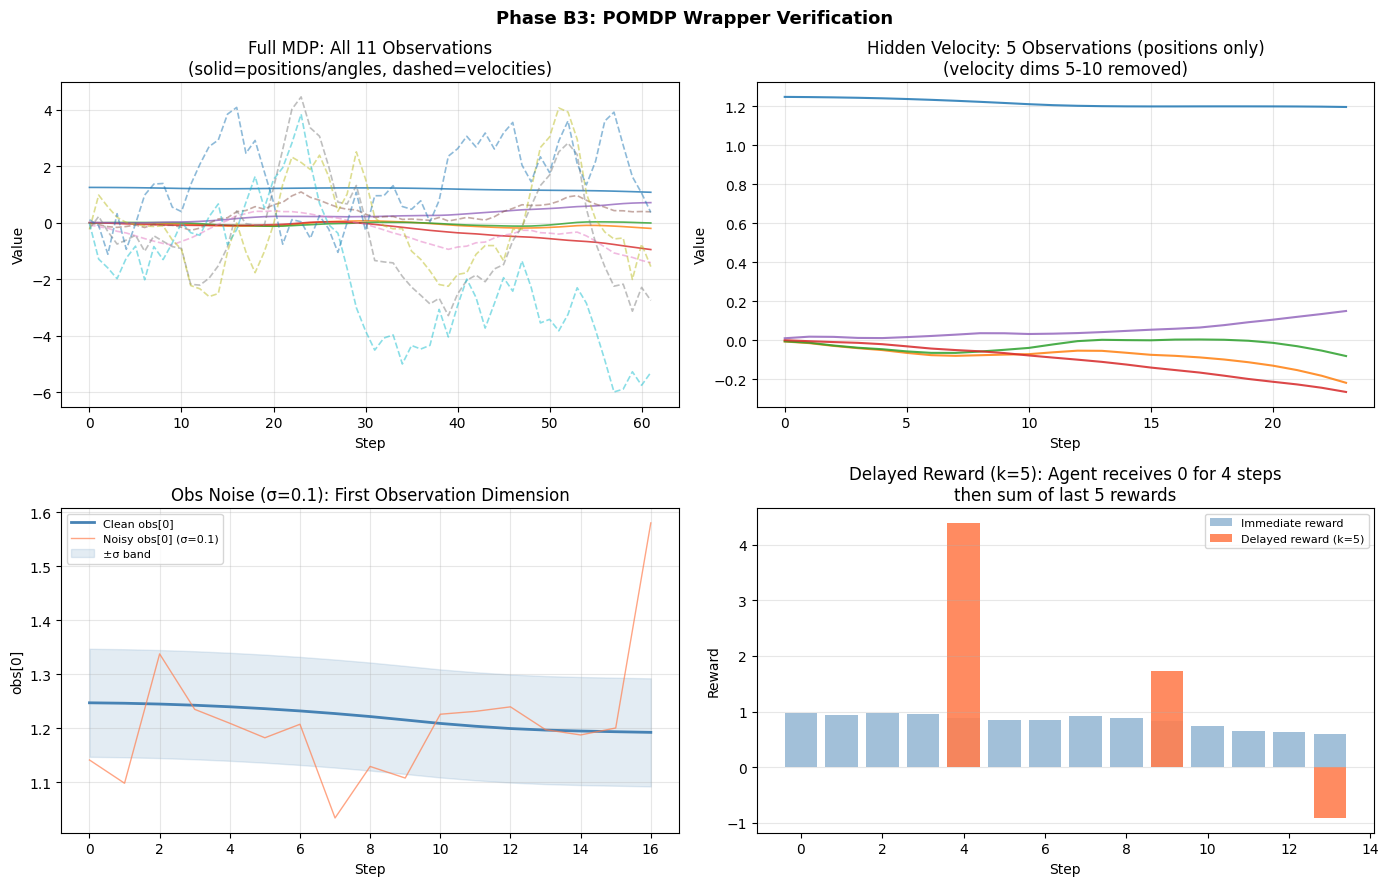

Saved → pomdp_wrappers.png


In [5]:
def collect_episode_data(env, n_steps=200):
    """Collect one episode of (obs, reward) data with random actions."""
    obs_list, rew_list = [], []
    obs, _ = env.reset(seed=0)
    for _ in range(n_steps):
        action = env.action_space.sample()
        obs, rew, terminated, truncated, _ = env.step(action)
        obs_list.append(obs.copy())
        rew_list.append(rew)
        if terminated or truncated: break
    return np.array(obs_list), np.array(rew_list)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ── Full MDP ──────────────────────────────────────────────────────────────────
env_full = make_env("none", {"type":"none"})
obs_full, rew_full = collect_episode_data(env_full); env_full.close()
ax = axes[0,0]
ax.plot(obs_full[:, :5], lw=1.2, alpha=0.8)   # positions
ax.plot(obs_full[:, 5:], lw=1.2, alpha=0.5, linestyle="--")  # velocities
ax.set_title("Full MDP: All 11 Observations\n"
             "(solid=positions/angles, dashed=velocities)")
ax.set_xlabel("Step"); ax.set_ylabel("Value"); ax.grid(alpha=0.3)

# ── Hidden Velocity ───────────────────────────────────────────────────────────
env_hv = make_env("hidden_vel", {"type":"hidden_vel"})
obs_hv, rew_hv = collect_episode_data(env_hv); env_hv.close()
ax = axes[0,1]
ax.plot(obs_hv, lw=1.5, alpha=0.85)
ax.set_title(f"Hidden Velocity: {obs_hv.shape[1]} Observations (positions only)\n"
             "(velocity dims 5-10 removed)")
ax.set_xlabel("Step"); ax.set_ylabel("Value"); ax.grid(alpha=0.3)

# ── Obs Noise ─────────────────────────────────────────────────────────────────
env_full2 = make_env("none", {"type":"none"})
obs_clean, _ = collect_episode_data(env_full2); env_full2.close()
env_noisy = make_env("obs_noise", {"type":"obs_noise","sigma":0.1})
obs_noisy, _ = collect_episode_data(env_noisy); env_noisy.close()
ax = axes[1,0]
T = min(len(obs_clean), len(obs_noisy))
ax.plot(obs_clean[:T, 0], lw=2, color="steelblue", label="Clean obs[0]")
ax.plot(obs_noisy[:T, 0], lw=1, color="coral", alpha=0.7, label="Noisy obs[0] (σ=0.1)")
ax.fill_between(range(T),
                obs_clean[:T,0] - 0.1, obs_clean[:T,0] + 0.1,
                alpha=0.15, color="steelblue", label="±σ band")
ax.set_title("Obs Noise (σ=0.1): First Observation Dimension")
ax.set_xlabel("Step"); ax.set_ylabel("obs[0]"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# ── Delayed Reward ────────────────────────────────────────────────────────────
env_full3 = make_env("none", {"type":"none"})
_, rew_clean = collect_episode_data(env_full3); env_full3.close()
env_delay = make_env("delay", {"type":"delay","k":5})
_, rew_delay = collect_episode_data(env_delay); env_delay.close()
ax = axes[1,1]
T = min(len(rew_clean), len(rew_delay), 60)
ax.bar(range(T), rew_clean[:T], alpha=0.5, label="Immediate reward", color="steelblue")
ax.bar(range(T), rew_delay[:T], alpha=0.9, label="Delayed reward (k=5)", color="coral")
ax.set_title("Delayed Reward (k=5): Agent receives 0 for 4 steps\nthen sum of last 5 rewards")
ax.set_xlabel("Step"); ax.set_ylabel("Reward"); ax.legend(fontsize=8); ax.grid(axis="y",alpha=0.3)

plt.suptitle("Phase B3: POMDP Wrapper Verification", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("pomdp_wrappers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → pomdp_wrappers.png")


In [6]:
# ────────────────────────────────────────────────────────────────────────────────
# Replay Buffer
# ────────────────────────────────────────────────────────────────────────────────
class ReplayBuffer:
    def __init__(self, state_dim, action_dim, max_size=1_000_000,
                 device=torch.device("cpu")):
        self.max_size=max_size; self.device=device; self.ptr=0; self.size=0
        self.s  = np.zeros((max_size, state_dim),  dtype=np.float32)
        self.a  = np.zeros((max_size, action_dim), dtype=np.float32)
        self.r  = np.zeros((max_size, 1),          dtype=np.float32)
        self.s2 = np.zeros((max_size, state_dim),  dtype=np.float32)
        self.d  = np.zeros((max_size, 1),          dtype=np.float32)

    def add(self, s, a, r, s2, done):
        self.s[self.ptr]=s; self.a[self.ptr]=a; self.r[self.ptr]=r
        self.s2[self.ptr]=s2; self.d[self.ptr]=float(done)
        self.ptr=(self.ptr+1)%self.max_size; self.size=min(self.size+1,self.max_size)

    def sample(self, batch_size):
        idx = np.random.randint(0, self.size, size=batch_size)
        return {k: torch.as_tensor(v[idx], device=self.device)
                for k,v in [("states",self.s),("actions",self.a),("rewards",self.r),
                             ("next_states",self.s2),("dones",self.d)]}
    def __len__(self): return self.size


# ────────────────────────────────────────────────────────────────────────────────
# Observation-Action History Buffer
# ────────────────────────────────────────────────────────────────────────────────
class ObsActionHistory:
    """Sliding window of (obs, action) pairs. Identical to Phase B2."""
    def __init__(self, obs_dim, action_dim, context_len):
        self.obs_dim=obs_dim; self.action_dim=action_dim; self.context_len=context_len
        self.reset()

    def reset(self):
        self.buf = deque(
            [np.zeros(self.obs_dim+self.action_dim, dtype=np.float32)
             for _ in range(self.context_len)],
            maxlen=self.context_len
        )

    def push(self, obs, action):
        self.buf.append(np.concatenate([obs,action]).astype(np.float32))

    def get_sequence(self, obs):
        seq = np.array(self.buf, dtype=np.float32)
        seq[-1] = np.concatenate([obs, np.zeros(self.action_dim)]).astype(np.float32)
        return seq  # (L, obs+act)


# ────────────────────────────────────────────────────────────────────────────────
# MLP Actor (Phase B1 architecture)
# ────────────────────────────────────────────────────────────────────────────────
class MLPActor(nn.Module):
    """Memoryless MLP actor. Takes single obs → action."""
    def __init__(self, state_dim, action_dim, hidden_dim=256, max_action=1.0):
        super().__init__()
        self.max_action = max_action
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, action_dim), nn.Tanh(),
        )
        self.apply(lambda m: (nn.init.orthogonal_(m.weight, np.sqrt(2)),
                              nn.init.zeros_(m.bias)) if isinstance(m,nn.Linear) else None)

    def forward(self, state):
        return self.max_action * self.net(state)


# ────────────────────────────────────────────────────────────────────────────────
# Transformer Actor (Phase B2 architecture)
# ────────────────────────────────────────────────────────────────────────────────
class SinusoidalPE(nn.Module):
    def __init__(self, d_model, max_len=64, dropout=0.1):
        super().__init__()
        self.drop = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(max_len, dtype=torch.float).unsqueeze(1)
        div = torch.exp(torch.arange(0,d_model,2,dtype=torch.float)*(-math.log(10000.)/d_model))
        pe[:,0::2]=torch.sin(pos*div); pe[:,1::2]=torch.cos(pos*div)
        self.register_buffer("pe",pe)
    def forward(self,x): return self.drop(x+self.pe[:x.size(1)].unsqueeze(0))

class CausalMHSA(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.d_model=d_model; self.n_heads=n_heads; self.d_head=d_model//n_heads
        self.scale=self.d_head**-0.5
        self.qkv=nn.Linear(d_model,3*d_model,bias=False)
        self.out=nn.Linear(d_model,d_model,bias=False)
        self.ad=nn.Dropout(dropout); self.rd=nn.Dropout(dropout)
    def forward(self,x):
        B,T,C=x.shape
        q,k,v=self.qkv(x).split(self.d_model,dim=-1)
        rsh=lambda t:t.view(B,T,self.n_heads,self.d_head).transpose(1,2)
        q,k,v=rsh(q),rsh(k),rsh(v)
        sc=torch.matmul(q,k.transpose(-2,-1))*self.scale
        m=torch.triu(torch.ones(T,T,device=x.device,dtype=torch.bool),diagonal=1)
        sc=sc.masked_fill(m,float("-inf"))
        w=self.ad(F.softmax(sc,dim=-1))
        o=torch.matmul(w,v).transpose(1,2).contiguous().view(B,T,C)
        return self.rd(self.out(o)),w

class TFBlock(nn.Module):
    def __init__(self,d,h,ff,dr):
        super().__init__()
        self.ln1=nn.LayerNorm(d); self.attn=CausalMHSA(d,h,dr)
        self.ln2=nn.LayerNorm(d)
        self.ff=nn.Sequential(nn.Linear(d,ff),nn.GELU(),nn.Dropout(dr),nn.Linear(ff,d),nn.Dropout(dr))
    def forward(self,x):
        a,w=self.attn(self.ln1(x)); x=x+a; return x+self.ff(self.ln2(x)),w

class TransformerActor(nn.Module):
    """Causal Transformer actor. Takes history sequence → action at last position."""
    def __init__(self, obs_dim, action_dim, max_action, context_len,
                 d_model=128, n_heads=4, n_layers=2, d_ff=256, dropout=0.1):
        super().__init__()
        self.obs_dim=obs_dim; self.action_dim=action_dim
        self.max_action=max_action; self.context_len=context_len
        self.proj = nn.Linear(obs_dim+action_dim, d_model)
        self.pe   = SinusoidalPE(d_model, max_len=context_len+8, dropout=dropout)
        self.blks = nn.ModuleList([TFBlock(d_model,n_heads,d_ff,dropout) for _ in range(n_layers)])
        self.ln   = nn.LayerNorm(d_model)
        self.head = nn.Sequential(nn.Linear(d_model,d_model),nn.ReLU(),
                                  nn.Linear(d_model,action_dim),nn.Tanh())
        # Fix: Only initialize bias if it exists (i.e., not None)
        def _init_weights(m):
            if isinstance(m, nn.Linear):
                nn.init.orthogonal_(m.weight, np.sqrt(2))
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
        self.apply(_init_weights)

        n=sum(p.numel() for p in self.parameters())
        print(f"  TransformerActor  L={context_len}  d={d_model}: {n:,} params")

    def forward(self, seq):  # seq: (B,L,obs+act)
        x = self.pe(self.proj(seq))
        for blk in self.blks: x,_=blk(x)
        return self.max_action * self.head(self.ln(x[:,-1,:]))

    def get_attn(self, seq):
        x=self.pe(self.proj(seq)); ws=[]
        for blk in self.blks:
            x,w=blk(x); ws.append(w)
        return self.max_action*self.head(self.ln(x[:,-1,:])), ws


# ────────────────────────────────────────────────────────────────────────────────
# Twin Critic (identical for both agent types)
# ────────────────────────────────────────────────────────────────────────────────
class Critic(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=256):
        super().__init__()
        inp=state_dim+action_dim
        def Q(): return nn.Sequential(
            nn.Linear(inp,hidden_dim),nn.ReLU(),
            nn.Linear(hidden_dim,hidden_dim),nn.ReLU(),
            nn.Linear(hidden_dim,1))
        self.q1=Q(); self.q2=Q()
        self.apply(lambda m: (nn.init.orthogonal_(m.weight,np.sqrt(2)),
                              nn.init.zeros_(m.bias)) if isinstance(m,nn.Linear) else None)
    def forward(self,s,a):
        sa=torch.cat([s,a],dim=-1); return self.q1(sa),self.q2(sa)
    def Q1(self,s,a): return self.q1(torch.cat([s,a],dim=-1))

print("All network classes defined.")

All network classes defined.


In [7]:
class MLPTD3Agent:
    """Phase B1 MLP actor + twin MLP critic. Memoryless baseline."""
    def __init__(self, obs_dim, action_dim, max_action, cfg, device):
        self.cfg=cfg; self.device=device; self.max_action=max_action; self.total_it=0
        self.actor         = MLPActor(obs_dim,action_dim,cfg["critic_hidden"],max_action).to(device)
        self.actor_target  = copy.deepcopy(self.actor)
        self.critic        = Critic(obs_dim,action_dim,cfg["critic_hidden"]).to(device)
        self.critic_target = copy.deepcopy(self.critic)
        for p in self.actor_target.parameters():  p.requires_grad=False
        for p in self.critic_target.parameters(): p.requires_grad=False
        self.ao = torch.optim.Adam(self.actor.parameters(),  lr=cfg["actor_lr"])
        self.co = torch.optim.Adam(self.critic.parameters(), lr=cfg["critic_lr"])

    def select_action(self, obs, add_noise=True):
        s = torch.tensor(obs, dtype=torch.float32, device=self.device).unsqueeze(0)
        self.actor.eval()
        with torch.no_grad(): a = self.actor(s).squeeze(0).cpu().numpy()
        self.actor.train()
        if add_noise:
            a += np.random.normal(0, self.cfg["expl_noise"]*self.max_action, size=a.shape)
            a  = np.clip(a, -self.max_action, self.max_action)
        return a

    def train_step(self, buf):
        self.total_it += 1
        b = buf.sample(self.cfg["batch_size"])
        s,a,r,s2,d = b["states"],b["actions"],b["rewards"],b["next_states"],b["dones"]
        with torch.no_grad():
            noise = (torch.randn_like(a)*self.cfg["policy_noise"]).clamp(-self.cfg["noise_clip"],self.cfg["noise_clip"])
            a2 = (self.actor_target(s2)+noise).clamp(-self.max_action,self.max_action)
            q1t,q2t = self.critic_target(s2,a2)
            y = r + self.cfg["discount"]*torch.min(q1t,q2t)*(1.-d)
        q1,q2 = self.critic(s,a)
        cl = F.mse_loss(q1,y)+F.mse_loss(q2,y)
        self.co.zero_grad(); cl.backward()
        nn.utils.clip_grad_norm_(self.critic.parameters(),10.); self.co.step()
        log={"cl":cl.item(),"al":None}
        if self.total_it % self.cfg["policy_delay"] == 0:
            al = -self.critic.Q1(s,self.actor(s)).mean()
            self.ao.zero_grad(); al.backward()
            nn.utils.clip_grad_norm_(self.actor.parameters(),10.); self.ao.step()
            log["al"]=al.item()
            tau=self.cfg["tau"]
            for p,tp in zip(self.actor.parameters(),self.actor_target.parameters()):
                tp.data.mul_(1-tau).add_(p.data,alpha=tau)
            for p,tp in zip(self.critic.parameters(),self.critic_target.parameters()):
                tp.data.mul_(1-tau).add_(p.data,alpha=tau)
        return log

    def save(self, path):
        Path(path).parent.mkdir(parents=True,exist_ok=True)
        torch.save({"actor":self.actor.state_dict(),"at":self.actor_target.state_dict(),
                    "critic":self.critic.state_dict(),"ct":self.critic_target.state_dict(),
                    "ao":self.ao.state_dict(),"co":self.co.state_dict(),
                    "it":self.total_it},path)


class TransformerTD3Agent:
    """Transformer actor + twin MLP critic. Memory-augmented policy."""
    def __init__(self, obs_dim, action_dim, max_action, context_len, cfg, tf_cfg, device):
        self.cfg=cfg; self.device=device; self.max_action=max_action
        self.context_len=context_len; self.total_it=0
        self.obs_dim=obs_dim; self.action_dim=action_dim
        self.actor = TransformerActor(obs_dim,action_dim,max_action,context_len,**tf_cfg).to(device)
        self.actor_target  = copy.deepcopy(self.actor)
        self.critic        = Critic(obs_dim,action_dim,cfg["critic_hidden"]).to(device)
        self.critic_target = copy.deepcopy(self.critic)
        for p in self.actor_target.parameters():  p.requires_grad=False
        for p in self.critic_target.parameters(): p.requires_grad=False
        self.ao = torch.optim.Adam(self.actor.parameters(),  lr=cfg["tf_actor_lr"])
        self.co = torch.optim.Adam(self.critic.parameters(), lr=cfg["critic_lr"])

    def _pad(self, states):
        """Pad flat states to (B,L,obs+act) sequences for batch training."""
        B=states.shape[0]; D=self.obs_dim+self.action_dim
        z = torch.zeros(B,self.context_len-1,D,device=self.device)
        q = torch.cat([states,torch.zeros(B,self.action_dim,device=self.device)],dim=-1).unsqueeze(1)
        return torch.cat([z,q],dim=1)

    def select_action(self, history_seq, add_noise=True):
        """history_seq: (L, obs+act) from ObsActionHistory.get_sequence()"""
        t = torch.tensor(history_seq,dtype=torch.float32,device=self.device).unsqueeze(0)
        self.actor.eval()
        with torch.no_grad(): a=self.actor(t).squeeze(0).cpu().numpy()
        self.actor.train()
        if add_noise:
            a += np.random.normal(0,self.cfg["expl_noise"]*self.max_action,size=a.shape)
            a  = np.clip(a,-self.max_action,self.max_action)
        return a

    def train_step(self, buf):
        self.total_it+=1
        b=buf.sample(self.cfg["batch_size"])
        s,a,r,s2,d=b["states"],b["actions"],b["rewards"],b["next_states"],b["dones"]
        with torch.no_grad():
            noise=(torch.randn_like(a)*self.cfg["policy_noise"]).clamp(-self.cfg["noise_clip"],self.cfg["noise_clip"])
            a2=(self.actor_target(self._pad(s2))+noise).clamp(-self.max_action,self.max_action)
            q1t,q2t=self.critic_target(s2,a2)
            y=r+self.cfg["discount"]*torch.min(q1t,q2t)*(1.-d)
        q1,q2=self.critic(s,a)
        cl=F.mse_loss(q1,y)+F.mse_loss(q2,y)
        self.co.zero_grad(); cl.backward()
        nn.utils.clip_grad_norm_(self.critic.parameters(),10.); self.co.step()
        log={"cl":cl.item(),"al":None}
        if self.total_it%self.cfg["policy_delay"]==0:
            al=-self.critic.Q1(s,self.actor(self._pad(s))).mean()
            self.ao.zero_grad(); al.backward()
            nn.utils.clip_grad_norm_(self.actor.parameters(),10.); self.ao.step()
            log["al"]=al.item()
            tau=self.cfg["tau"]
            for p,tp in zip(self.actor.parameters(),self.actor_target.parameters()):
                tp.data.mul_(1-tau).add_(p.data,alpha=tau)
            for p,tp in zip(self.critic.parameters(),self.critic_target.parameters()):
                tp.data.mul_(1-tau).add_(p.data,alpha=tau)
        return log

    def save(self, path):
        Path(path).parent.mkdir(parents=True,exist_ok=True)
        torch.save({"actor":self.actor.state_dict(),"at":self.actor_target.state_dict(),
                    "critic":self.critic.state_dict(),"ct":self.critic_target.state_dict(),
                    "ao":self.ao.state_dict(),"co":self.co.state_dict(),
                    "it":self.total_it,"L":self.context_len},path)

print("MLPTD3Agent and TransformerTD3Agent defined.")


MLPTD3Agent and TransformerTD3Agent defined.


In [8]:
def evaluate(agent, pomdp_cfg, seed, n_episodes=10, use_history=False):
    """
    Evaluate an agent on a POMDP condition.

    Args:
        agent       : MLPTD3Agent or TransformerTD3Agent
        pomdp_cfg   : dict specifying the POMDP wrapper
        seed        : base random seed
        n_episodes  : number of deterministic evaluation episodes
        use_history : if True, maintain ObsActionHistory (Transformer agent)
    """
    env     = make_env(pomdp_cfg.get("type","none"), pomdp_cfg, seed=seed)
    returns = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed+ep)
        obs_dim = obs.shape[0]

        if use_history:
            hist = ObsActionHistory(obs_dim, ACTION_DIM, agent.context_len)

        ep_ret = 0.0; done = False

        while not done:
            if use_history:
                seq    = hist.get_sequence(obs)
                action = agent.select_action(seq, add_noise=False)
                hist.push(obs, action)
            else:
                action = agent.select_action(obs, add_noise=False)

            obs, rew, terminated, truncated, _ = env.step(action)
            ep_ret += rew
            done = terminated or truncated

        returns.append(ep_ret)

    env.close()
    arr = np.array(returns)
    return {"mean":arr.mean(),"std":arr.std(),"min":arr.min(),"max":arr.max()}

print("evaluate() defined.")


evaluate() defined.


In [9]:
def train(agent, pomdp_cfg, label, cfg, use_history=False):
    """
    Train one agent on one POMDP condition.

    Args:
        agent       : MLPTD3Agent or TransformerTD3Agent
        pomdp_cfg   : dict specifying the POMDP wrapper
        label       : string label for logging/saving
        cfg         : TD3_CFG dict
        use_history : True for Transformer agent
    Returns:
        history dict
    """
    os.makedirs(cfg["save_dir"], exist_ok=True)
    env = make_env(pomdp_cfg.get("type","none"), pomdp_cfg, seed=cfg["seed"])
    obs_dim = env.observation_space.shape[0]

    buf = ReplayBuffer(obs_dim, ACTION_DIM, cfg["buffer_size"], DEVICE)
    history = {"ep_rets":[],"ep_steps":[],"eval_means":[],"eval_stds":[],"eval_steps":[]}

    obs, _ = env.reset(seed=cfg["seed"])
    if use_history:
        hist_buf = ObsActionHistory(obs_dim, ACTION_DIM, agent.context_len)

    ep_ret=ep_n=total_ep=0; t0=time.time()
    print(f"\n{'='*60}\n  [{label}]\n{'='*60}")

    for t in range(1, cfg["total_steps"]+1):

        # ── Action selection ────────────────────────────────────────────────
        if t < cfg["warmup_steps"]:
            action = env.action_space.sample()
        elif use_history:
            seq    = hist_buf.get_sequence(obs)
            action = agent.select_action(seq, add_noise=True)
        else:
            action = agent.select_action(obs, add_noise=True)

        # ── Environment step ────────────────────────────────────────────────
        next_obs, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        buf.add(obs, action, reward, next_obs, float(terminated))

        if use_history: hist_buf.push(obs, action)
        obs=next_obs; ep_ret+=reward; ep_n+=1

        # ── Episode reset ───────────────────────────────────────────────────
        if done:
            history["ep_rets"].append(ep_ret)
            history["ep_steps"].append(t)
            total_ep+=1
            if t%cfg["log_every"]<ep_n:
                print(f"  [{label}] Step {t:>8,} | Ep {total_ep:>4} | "
                      f"Ret {ep_ret:>8.1f} | FPS {t/(time.time()-t0):>5.0f}")
            obs,_=env.reset()
            if use_history: hist_buf.reset()
            ep_ret=ep_n=0

        # ── TD3 update ──────────────────────────────────────────────────────
        if t>=cfg["warmup_steps"] and len(buf)>=cfg["batch_size"]:
            agent.train_step(buf)

        # ── Evaluation ─────────────────────────────────────────────────────
        if t%cfg["eval_every"]==0:
            ev = evaluate(agent, pomdp_cfg, seed=cfg["seed"]+1000,
                          n_episodes=cfg["eval_episodes"], use_history=use_history)
            history["eval_means"].append(ev["mean"])
            history["eval_stds"].append(ev["std"])
            history["eval_steps"].append(t)
            elapsed=(time.time()-t0)/60
            print(f"  [{label}] ── EVAL Step {t:>8,} | "
                  f"Mean {ev['mean']:>8.1f}±{ev['std']:.1f} | {elapsed:.1f} min")
            agent.save(f"{cfg['save_dir']}/{label}_step_{t:07d}.pt")

    agent.save(f"{cfg['save_dir']}/{label}_final.pt")
    env.close()
    history["final_return"] = history["eval_means"][-1] if history["eval_means"] else 0
    print(f"\n  [{label}] Done. Final eval: {history['final_return']:.1f}")
    return history

print("train() defined.")


train() defined.


In [10]:
all_results = {}   # all_results[condition_name][agent_name] = history

for cond_name, pomdp_cfg in POMDP_CFGS.items():
    all_results[cond_name] = {}
    # Determine obs_dim for this condition
    _tmp_env = make_env(pomdp_cfg.get("type","none"), pomdp_cfg)
    obs_dim  = _tmp_env.observation_space.shape[0]
    _tmp_env.close()
    print(f"\n\n{'#'*62}")
    print(f"#  Condition: {cond_name}  (obs_dim={obs_dim})")
    print(f"{'#'*62}")

    # ── MLP-TD3 baseline ──────────────────────────────────────────────────
    label_mlp = f"MLP_{cond_name}"
    mlp_agent = MLPTD3Agent(obs_dim, ACTION_DIM, MAX_ACTION, TD3_CFG, DEVICE)
    # mlp_agent.load(f"{TD3_CFG['save_dir']}/{label_mlp}_step_XXXXXXX.pt")  # resume
    hist_mlp  = train(mlp_agent, pomdp_cfg, label_mlp, TD3_CFG, use_history=False)
    all_results[cond_name]["MLP-TD3"] = hist_mlp

    # ── Transformer-TD3 ───────────────────────────────────────────────────
    label_tf  = f"TF_{cond_name}"
    tf_agent  = TransformerTD3Agent(obs_dim, ACTION_DIM, MAX_ACTION,
                                    BEST_L, TD3_CFG, TF_CFG, DEVICE)
    # tf_agent.load(f"{TD3_CFG['save_dir']}/{label_tf}_step_XXXXXXX.pt")   # resume
    hist_tf   = train(tf_agent, pomdp_cfg, label_tf, TD3_CFG, use_history=True)
    all_results[cond_name]["Transformer-TD3"] = hist_tf

print("\n\nAll POMDP experiments complete.")




##############################################################
#  Condition: HiddenVelocity  (obs_dim=5)
##############################################################


/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(



  [MLP_HiddenVelocity]
  [MLP_HiddenVelocity] Step    2,009 | Ep   81 | Ret     14.5 | FPS  3073
  [MLP_HiddenVelocity] Step    4,015 | Ep  169 | Ret     20.7 | FPS  3050
  [MLP_HiddenVelocity] Step    6,016 | Ep  253 | Ret     23.4 | FPS  3078
  [MLP_HiddenVelocity] Step    8,025 | Ep  347 | Ret     18.1 | FPS  3105
  [MLP_HiddenVelocity] ── EVAL Step   10,000 | Mean     12.0±0.2 | 0.1 min
  [MLP_HiddenVelocity] Step   10,008 | Ep  439 | Ret      5.4 | FPS  2788
  [MLP_HiddenVelocity] Step   12,017 | Ep  527 | Ret     16.8 | FPS  2609
  [MLP_HiddenVelocity] Step   14,021 | Ep  623 | Ret     15.7 | FPS  2488
  [MLP_HiddenVelocity] Step   16,024 | Ep  719 | Ret     30.6 | FPS  2468
  [MLP_HiddenVelocity] Step   18,001 | Ep  805 | Ret     12.9 | FPS  2392
  [MLP_HiddenVelocity] ── EVAL Step   20,000 | Mean     12.0±0.2 | 0.1 min
  [MLP_HiddenVelocity] Step   20,010 | Ep  895 | Ret      9.1 | FPS  2270
  [MLP_HiddenVelocity] Step   22,011 | Ep  985 | Ret     26.0 | FPS  2328
  [MLP_Hidde

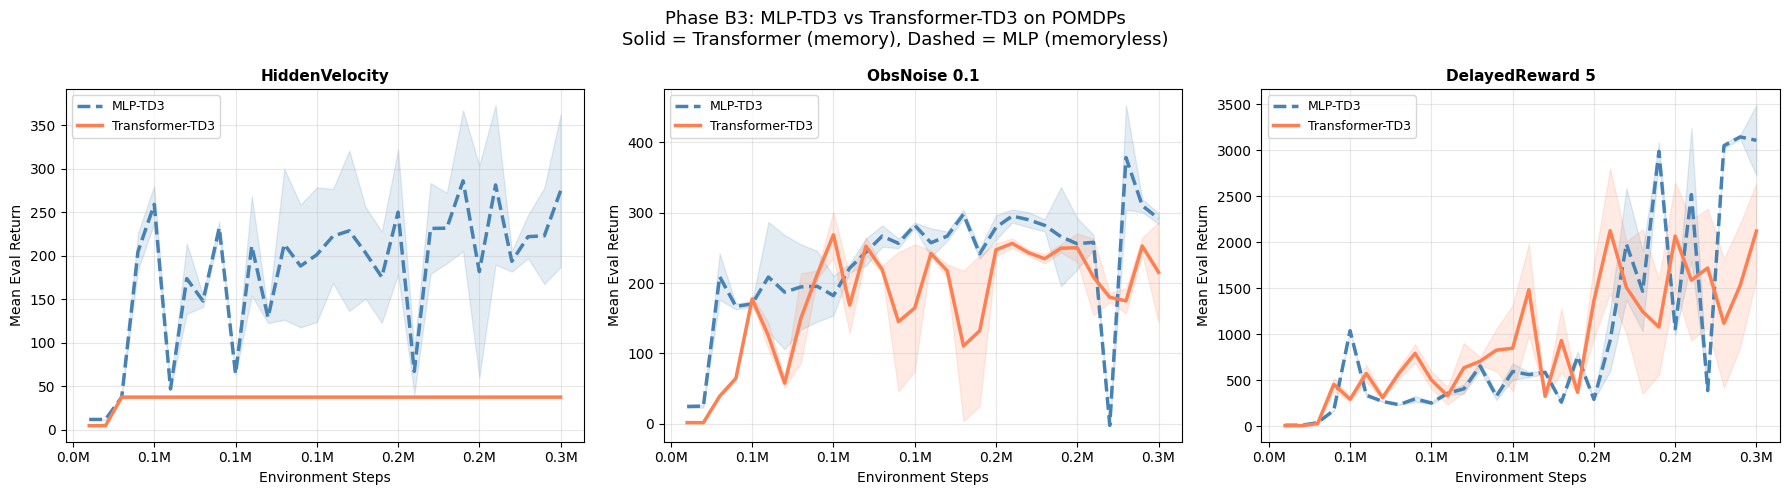

Saved → pomdp_learning_curves.png


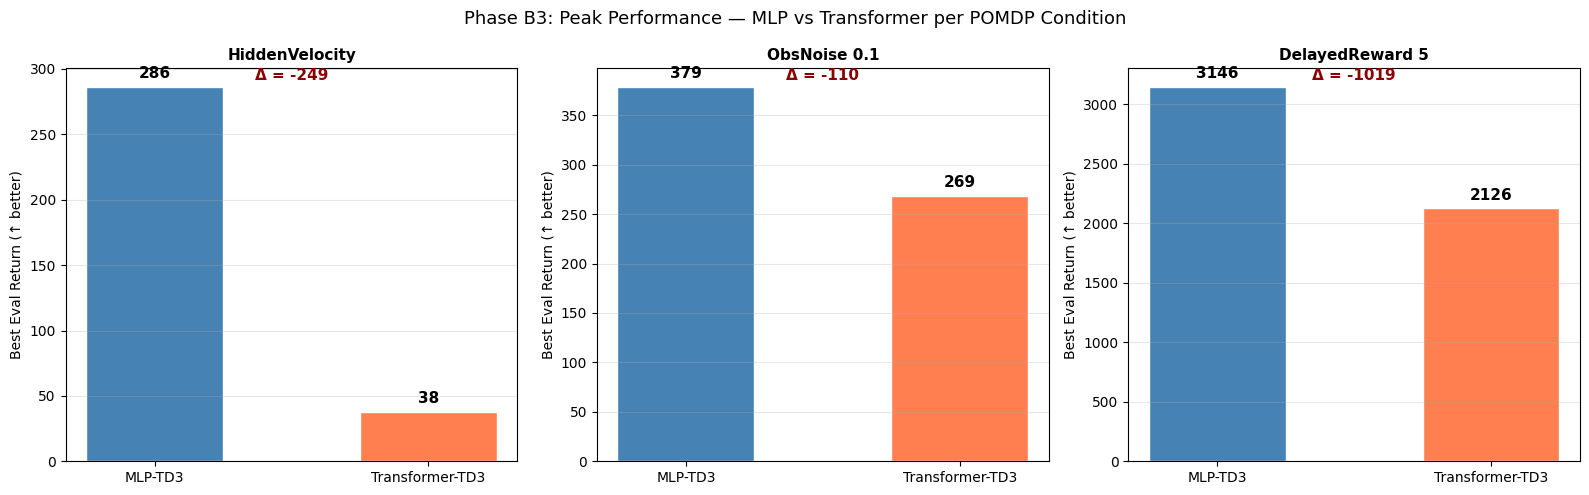

Saved → pomdp_bar_comparison.png


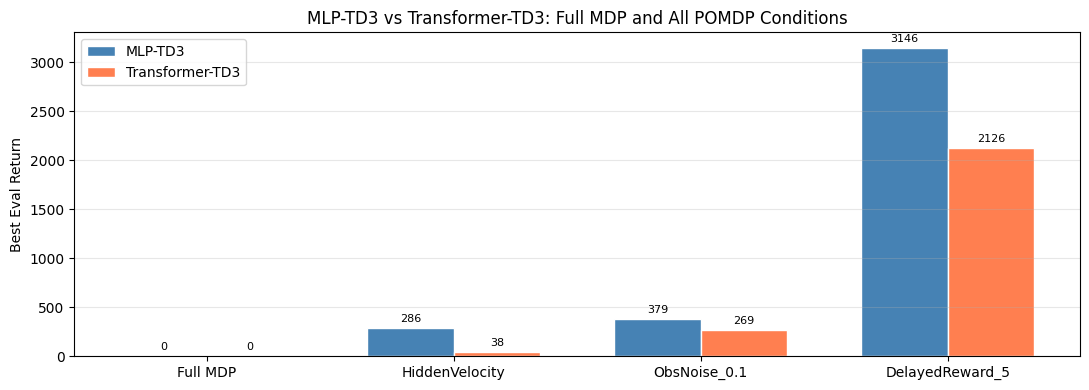

Saved → pomdp_full_comparison.png


In [11]:
CONDITIONS = list(POMDP_CFGS.keys())
AGENT_COLORS = {"MLP-TD3": "steelblue", "Transformer-TD3": "coral"}
AGENT_STYLES = {"MLP-TD3": "--", "Transformer-TD3": "-"}

# ── Figure 1: Learning curves (3 conditions × 2 agents = 6 curves) ────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cond in zip(axes, CONDITIONS):
    for agent_name, hist in all_results[cond].items():
        if not hist["eval_steps"]: continue
        means = np.array(hist["eval_means"])
        stds  = np.array(hist["eval_stds"])
        steps = np.array(hist["eval_steps"])
        c = AGENT_COLORS[agent_name]
        ax.plot(steps, means, AGENT_STYLES[agent_name], color=c,
                lw=2.5, label=agent_name)
        ax.fill_between(steps, means-stds, means+stds, alpha=0.15, color=c)
    ax.set_title(cond.replace("_"," "), fontsize=11, fontweight="bold")
    ax.set_xlabel("Environment Steps")
    ax.set_ylabel("Mean Eval Return")
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))

plt.suptitle("Phase B3: MLP-TD3 vs Transformer-TD3 on POMDPs\n"
             "Solid = Transformer (memory), Dashed = MLP (memoryless)",
             fontsize=13)
plt.tight_layout()
plt.savefig("pomdp_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved → pomdp_learning_curves.png")

# ── Figure 2: Final return comparison bar chart ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, cond in zip(axes, CONDITIONS):
    agents    = list(all_results[cond].keys())
    finals    = [max(all_results[cond][a]["eval_means"])
                 if all_results[cond][a]["eval_means"] else 0
                 for a in agents]
    colors    = [AGENT_COLORS[a] for a in agents]
    bars = ax.bar(agents, finals, color=colors, edgecolor="white", width=0.5)
    ax.bar_label(bars, fmt="%.0f", padding=4, fontsize=11, fontweight="bold")

    # Mark the advantage
    if len(finals) == 2:
        delta = finals[1] - finals[0]  # Transformer - MLP
        sign  = "+" if delta >= 0 else ""
        ax.annotate(f"Δ = {sign}{delta:.0f}",
                    xy=(0.5, max(finals)*1.02),
                    xycoords=("axes fraction","data"),
                    ha="center", fontsize=11, fontweight="bold",
                    color="darkgreen" if delta >= 0 else "darkred")
    ax.set_title(cond.replace("_"," "), fontsize=11, fontweight="bold")
    ax.set_ylabel("Best Eval Return (↑ better)")
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Phase B3: Peak Performance — MLP vs Transformer per POMDP Condition",
             fontsize=13)
plt.tight_layout()
plt.savefig("pomdp_bar_comparison.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved → pomdp_bar_comparison.png")

# ── Figure 3: Transformer advantage heatmap ───────────────────────────────────
# Load Phase B2 results for fully-observable baseline
try:
    with open("rl_phase2_summary.json") as f:
        b2 = json.load(f)
    mlp_full = b2.get("baseline_mlp_return", None)
    tf_best  = b2["results"][str(BEST_L)]["best_return"]
except (FileNotFoundError, KeyError):
    mlp_full = None; tf_best = None

conditions_all = ["Full MDP"] + CONDITIONS
rows = {"MLP-TD3":[], "Transformer-TD3":[]}
for cond in conditions_all:
    if cond == "Full MDP":
        rows["MLP-TD3"].append(mlp_full or 0)
        rows["Transformer-TD3"].append(tf_best or 0)
    else:
        for agent in ["MLP-TD3","Transformer-TD3"]:
            hist = all_results[cond].get(agent,{})
            val  = max(hist.get("eval_means",[0])) if hist.get("eval_means") else 0
            rows[agent].append(val)

fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(conditions_all))
w = 0.35
b1 = ax.bar(x-w/2, rows["MLP-TD3"],         w, label="MLP-TD3",
            color="steelblue", edgecolor="white")
b2_ = ax.bar(x+w/2, rows["Transformer-TD3"], w, label="Transformer-TD3",
             color="coral", edgecolor="white")
ax.bar_label(b1,  fmt="%.0f", padding=3, fontsize=8)
ax.bar_label(b2_, fmt="%.0f", padding=3, fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(conditions_all, fontsize=10)
ax.set_ylabel("Best Eval Return"); ax.legend(fontsize=10); ax.grid(axis="y",alpha=0.3)
ax.set_title("MLP-TD3 vs Transformer-TD3: Full MDP and All POMDP Conditions",fontsize=12)
plt.tight_layout()
plt.savefig("pomdp_full_comparison.png", dpi=150, bbox_inches="tight")
plt.show(); print("Saved → pomdp_full_comparison.png")


In [12]:
# ── Master results table ──────────────────────────────────────────────────────
print("\n" + "="*75)
print("PHASE B3 COMPLETE RESULTS")
print("="*75)
print(f"  {'Condition':<22}  {'MLP-TD3':>12}  {'Transformer-TD3':>16}  {'Advantage':>10}")
print("-"*75)

summary = {}

for cond in conditions_all:
    if cond == "Full MDP":
        mlp_val = mlp_full or 0
        tf_val  = tf_best  or 0
    else:
        mlp_hist = all_results[cond].get("MLP-TD3",{})
        tf_hist  = all_results[cond].get("Transformer-TD3",{})
        mlp_val  = max(mlp_hist.get("eval_means",[0])) if mlp_hist.get("eval_means") else 0
        tf_val   = max(tf_hist.get("eval_means",[0]))  if tf_hist.get("eval_means")  else 0

    delta = tf_val - mlp_val
    sign  = "+" if delta >= 0 else ""
    flag  = " ← TF wins" if delta > 50 else (" ← MLP wins" if delta < -50 else "  ← tie")
    print(f"  {cond:<22}  {mlp_val:>12.1f}  {tf_val:>16.1f}  {sign}{delta:>7.1f}{flag}")
    summary[cond] = {"mlp":mlp_val,"tf":tf_val,"delta":delta}

print("="*75)

# Save summary
with open("rl_phase3_summary.json","w") as f:
    json.dump({"best_L":BEST_L,"results":summary,
               "conditions":conditions_all}, f, indent=2)
print("\nSaved → rl_phase3_summary.json")



PHASE B3 COMPLETE RESULTS
  Condition                    MLP-TD3   Transformer-TD3   Advantage
---------------------------------------------------------------------------
  Full MDP                         0.0               0.0  +    0.0  ← tie
  HiddenVelocity                 286.2              37.6   -248.5 ← MLP wins
  ObsNoise_0.1                   378.6             268.6   -110.0 ← MLP wins
  DelayedReward_5               3145.6            2126.2  -1019.4 ← MLP wins

Saved → rl_phase3_summary.json


Computing attention patterns across POMDP conditions …

  TransformerActor  L=4  d=128: 282,243 params
  Loaded ./checkpoints_rl_b3/TF_HiddenVelocity_final.pt
  HiddenVelocity: mean_entropy=1.191  peak_attn_at_pos=+0
  TransformerActor  L=4  d=128: 283,011 params


/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/usr/local/lib/python3.12/dist-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


  Loaded ./checkpoints_rl_b3/TF_ObsNoise_0.1_final.pt
  ObsNoise_0.1: mean_entropy=0.660  peak_attn_at_pos=-3
  TransformerActor  L=4  d=128: 283,011 params
  Loaded ./checkpoints_rl_b3/TF_DelayedReward_5_final.pt
  DelayedReward_5: mean_entropy=0.774  peak_attn_at_pos=+0


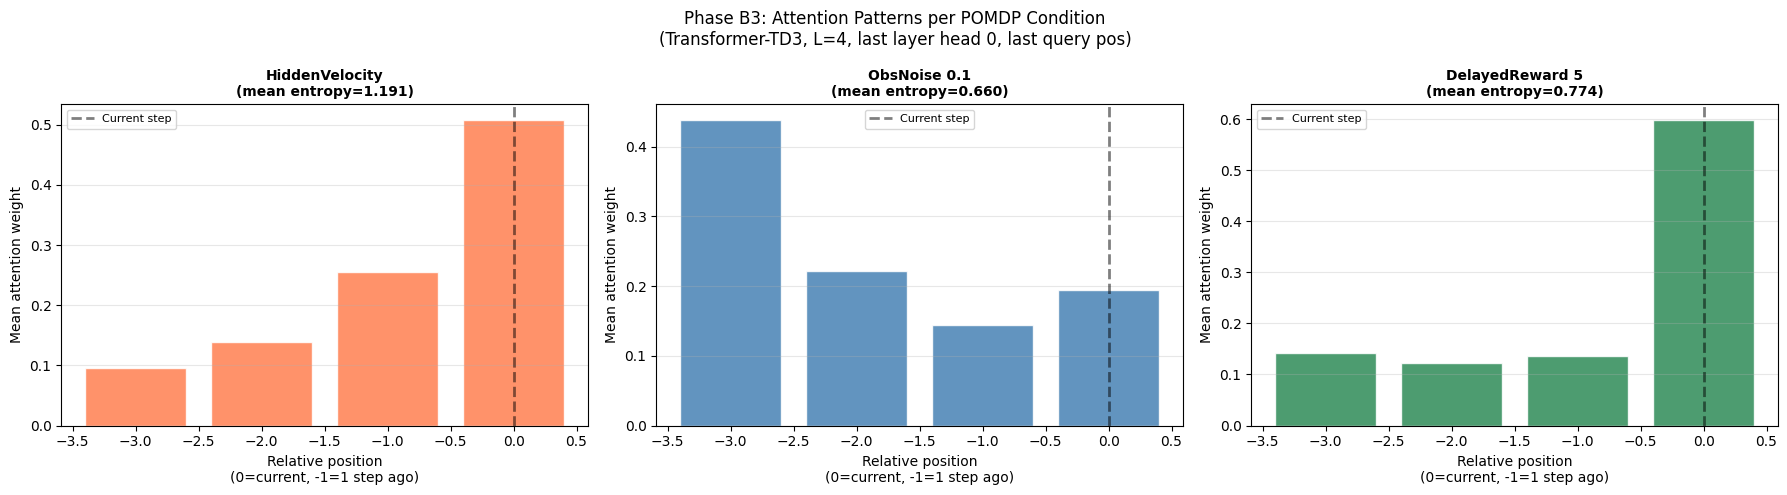

Saved → pomdp_attention_patterns.png


In [13]:
def analyse_attention(agent, pomdp_cfg, label, n_steps=300):
    """
    Run a rollout and collect mean attention weight per history position.
    Returns (mean_attn: (L,), entropy_per_step: (n_steps,))
    """
    env = make_env(pomdp_cfg.get("type","none"), pomdp_cfg)
    obs_dim = env.observation_space.shape[0]
    obs, _  = env.reset(seed=42)
    hist    = ObsActionHistory(obs_dim, ACTION_DIM, agent.context_len)
    step_attns = []; step_entropies = []

    agent.actor.eval()
    with torch.no_grad():
        for _ in range(n_steps):
            seq   = hist.get_sequence(obs)
            seq_t = torch.tensor(seq,dtype=torch.float32,device=DEVICE).unsqueeze(0)
            action, attn_list = agent.actor.get_attn(seq_t)
            action = action.squeeze(0).cpu().numpy()

            # Last layer, first head, last query position
            w = attn_list[-1][0, 0, -1, :].cpu().numpy()  # (L,)
            step_attns.append(w)

            # Attention entropy (measure of focus)
            eps = 1e-9
            ent = -(w * np.log(w + eps)).sum()
            step_entropies.append(ent)

            hist.push(obs, action)
            obs, _, term, trunc, _ = env.step(action)
            if term or trunc: break

    agent.actor.train(); env.close()
    return np.array(step_attns).mean(axis=0), np.array(step_entropies)


# ── Compute attention stats for each POMDP condition ─────────────────────────
print("Computing attention patterns across POMDP conditions …\n")

# We need the trained Transformer agent for each condition
# (stored in all_results via the training runs above)
# Reload agents — or use the ones saved to disk
cond_attns    = {}
cond_entropies = {}

for cond_name, pomdp_cfg in POMDP_CFGS.items():
    _tmp_env = make_env(pomdp_cfg.get("type","none"), pomdp_cfg)
    obs_dim  = _tmp_env.observation_space.shape[0]; _tmp_env.close()

    # Try to load the saved Transformer agent for this condition
    ckpt_path = f"{TD3_CFG['save_dir']}/TF_{cond_name}_final.pt"
    if os.path.exists(ckpt_path):
        tf_agent = TransformerTD3Agent(obs_dim, ACTION_DIM, MAX_ACTION,
                                       BEST_L, TD3_CFG, TF_CFG, DEVICE)
        ckpt = torch.load(ckpt_path, map_location=DEVICE)
        tf_agent.actor.load_state_dict(ckpt["actor"])
        print(f"  Loaded {ckpt_path}")
    else:
        # Fall back to the agent still in memory
        tf_agent = list(filter(
            lambda x: isinstance(x, TransformerTD3Agent) and x.obs_dim==obs_dim,
            [v for d in all_results.values() for v in d.values()]
        ))
        if not tf_agent:
            print(f"  No agent found for {cond_name} — skipping attention analysis")
            continue
        tf_agent = tf_agent[0]

    mean_attn, entropies = analyse_attention(tf_agent, pomdp_cfg, cond_name)
    cond_attns[cond_name]     = mean_attn
    cond_entropies[cond_name] = entropies
    print(f"  {cond_name}: mean_entropy={entropies.mean():.3f}  "
          f"peak_attn_at_pos={np.argmax(mean_attn)-BEST_L+1:+d}")


# ── Plot attention patterns per condition ─────────────────────────────────────
if cond_attns:
    fig, axes = plt.subplots(1, len(cond_attns), figsize=(6*len(cond_attns), 5))
    if len(cond_attns)==1: axes=[axes]

    COND_COLORS = {"HiddenVelocity":"coral","ObsNoise_0.1":"steelblue",
                   "DelayedReward_5":"seagreen"}

    for ax, (cond, attn) in zip(axes, cond_attns.items()):
        rel_pos = np.arange(BEST_L) - (BEST_L - 1)
        color   = COND_COLORS.get(cond, "steelblue")
        ax.bar(rel_pos, attn, color=color, edgecolor="white", alpha=0.85)
        ax.axvline(0, color="black", lw=2, linestyle="--", alpha=0.5,
                   label="Current step")
        ax.set_title(f"{cond.replace('_',' ')}\n"
                     f"(mean entropy={cond_entropies[cond].mean():.3f})",
                     fontsize=10, fontweight="bold")
        ax.set_xlabel("Relative position\n(0=current, -1=1 step ago)")
        ax.set_ylabel("Mean attention weight")
        ax.legend(fontsize=8); ax.grid(axis="y",alpha=0.3)

    plt.suptitle(f"Phase B3: Attention Patterns per POMDP Condition\n"
                 f"(Transformer-TD3, L={BEST_L}, last layer head 0, last query pos)",
                 fontsize=12)
    plt.tight_layout()
    plt.savefig("pomdp_attention_patterns.png", dpi=130, bbox_inches="tight")
    plt.show(); print("Saved → pomdp_attention_patterns.png")
